In [19]:
import os
import sys
import pandas as pd
import numpy as np
import math
import tensorflow as tf
import datetime
import matplotlib.pyplot as plt
verbose=1

In [20]:
## import data here
basesavepath = './.rawdata'
datasource= [f for f in os.listdir(basesavepath) if f.endswith(".pkl")]
df_temp = pd.read_pickle(f"{basesavepath}/{datasource[0]}")
df_temp.index = pd.to_datetime(df_temp['open_time'],format="%Y-%m-%d %H:%S:%S")

if verbose:
    print('dftemp head')
    print(df_temp.head(5))

#line below this builds a new df
df = df_temp.iloc[:, [df_temp.columns.get_loc("open"),df_temp.columns.get_loc("volume")]]

if verbose:
    print('df head')
    print(df.head(5))

dftemp head
                              open_time     open     high      low    close  \
open_time                                                                     
2019-09-23 08:00:00 2019-09-23 08:00:00  9930.13  9930.13  9930.13  9930.13   
2019-09-23 13:00:00 2019-09-23 13:00:00  9930.13  9930.13  9930.13  9930.13   
2019-09-23 14:00:00 2019-09-23 14:00:00  9930.13  9930.13  9930.13  9930.13   
2019-09-23 15:00:00 2019-09-23 15:00:00  9930.13  9930.13  9930.13  9930.13   
2019-09-23 16:00:00 2019-09-23 16:00:00  9930.13  9930.13  9930.13  9930.13   

                        volume              close_time  quote_volume  count  \
open_time                                                                     
2019-09-23 08:00:00  1000000.0 2019-09-23 08:57:17.115       9.93013      1   
2019-09-23 13:00:00        0.0 2019-09-23 13:59:59.999       0.00000      0   
2019-09-23 14:00:00        0.0 2019-09-23 14:59:59.999       0.00000      0   
2019-09-23 15:00:00        0.0 2019-09-

In [21]:
# This preps data in correct format for RNN
# [[X][X][X][X]][Y]
# [[1][2][3][4]][5]
# [[2][3][4][5]][6]
windowsize=5
df_as_np = df.to_numpy()
X=[]
Y=[]
for i in range(len(df_as_np)-windowsize):
    row = [a for a in df_as_np[i:i+windowsize]]
    X.append(row)
    label = df_as_np[i+windowsize,0]
    Y.append(label)

prepX=np.array(X)
prepY=np.array(Y)

In [22]:
# split data into train, val, test sets
X_train, Y_train  = prepX[:45000], prepY[:45000]
X_val, Y_val  = prepX[45000:52000], prepY[45000:52000]
X_test, Y_test = prepX[52000:], prepY[52000:]

if verbose:
    print(X_train.shape, Y_train.shape) 
    print(X_val.shape, Y_val.shape) 
    print(X_test.shape, Y_test.shape) 
    print(X_train[1])

(45000, 5, 2) (45000,)
(7000, 5, 2) (7000,)
(6670, 5, 2) (6670,)
[[9930.13    0.  ]
 [9930.13    0.  ]
 [9930.13    0.  ]
 [9930.13    0.  ]
 [9930.13    0.  ]]


In [23]:
# import things for model here
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam

In [ ]:
#Normalize data here
norm_layer = tf.keras.layers.Normalization(axis=-1)
norm_layer.adapt(X_train)

In [ ]:
# create and train model here
model1 = Sequential()
model1.norm_layer 
model1.add(InputLayer((X_train.shape[1],X_train.shape[2])))
model1.add(LSTM(256, return_sequences=True))
model1.add(Dropout(0.1))
model1.add(LSTM(128,return_sequences=True))
model1.add(Dropout(0.1))
model1.add(Dense(16,'relu'))
model1.add(Dense(1,'linear'))

model1.summary()

cp = ModelCheckpoint(filepath='.data/LSTM-model1.keras', save_best_only=True)
model1.compile(loss=MeanSquaredError(), optimizer=Adam(), metrics=[RootMeanSquaredError()])

if verbose:
    print(tf.config.list_physical_devices())    

history=model1.fit(X_train,Y_train,validation_data=(X_val,Y_val), epochs=5, callbacks=[cp], verbose=verbose)     


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 5, 256)         │       265,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 5, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 5, 128)         │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5, 16)          │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5, 1)           │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 464,417 (1.77 MB)

 Trainable params: 464,417 (1.77 MB)

 Non-trainable params: 0 (0.00 B)

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - loss: 1394175872.0000 - root_mean_squared_error: 37338.6641 - val_loss: 9466743808.0000 - val_root_mean_squared_error: 97297.1953
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 1054805952.0000 - root_mean_squared_error: 32477.7754 - val_loss: 8009766400.0000 - val_root_mean_squared_error: 89497.3047
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - loss: 676840960.0000 - root_mean_squared_error: 26016.1680 - val_loss: 6432151552.0000 - val_root_mean_squared_error: 80200.6953
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step - loss: 450193184.0000 - root_mean_squared_error: 21217.7578 - val_loss: 5223459840.0000 - val_root_mean_squared_error: 72273.5078
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - loss: 386903584.0000 - root_mean_squared_error: 19669.8652 - val_loss: 4720241664.0000 - val_root_mean_squared_error: 68704.0234


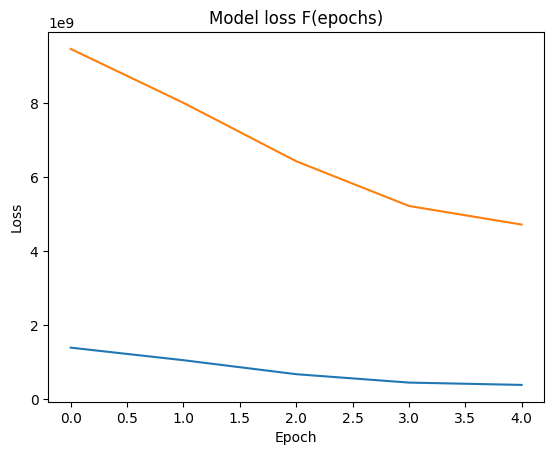

In [33]:
# this section evaluates and plots how well the model is doing
model1 = load_model('.data/LSTM-model1.keras') # load best model
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss F(epochs)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()